# Initialize Model

In [7]:
from Config.config import CONFIG
CONFIG = CONFIG("Wikipedia")


from DyGLib.models.GraphMixer import GraphMixer
from DyGLib.models.TGAT import TGAT
from DyGLib.models.TCL import TCL
from DyGLib.models.CAWN import CAWN
from DyGLib.models.DyGFormer import DyGFormer
from DyGLib.models.MemoryModel import MemoryModel, compute_src_dst_node_time_shifts

from DyGLib.models.modules import TGNN, NeuralNetworkSrcDst, BatchSubgraphs
from DyGLib.utils.DataLoader import get_link_prediction_data
from DyGLib.utils.utils import get_neighbor_sampler, NegativeEdgeSampler

import torch
import numpy as np
import pandas as pd
import seaborn as sns

import random

from IPython.display import SVG
import time

# Select a device available on this machine. The checkpoint is loaded on CPU
# first, which remaps tensors saved on CUDA before moving the model to MPS.
if torch.backends.mps.is_available():
    CONFIG.model.device = "mps"
else:
    CONFIG.model.device = "cpu"
CONFIG.tempME.device = CONFIG.model.device

# # Initialization
trained_model_path = CONFIG.model.trained_model_path
edge_feat_path = CONFIG.data.folder + CONFIG.data.edge_feat_file
node_feat_path = CONFIG.data.folder + CONFIG.data.node_feat_file
index_path = CONFIG.data.folder + CONFIG.data.index_file
feature_names_path = CONFIG.data.folder + CONFIG.data.feature_names_file

# get data for training, validation and testing
node_raw_features, edge_raw_features, full_data, train_data, val_data, test_data = \
    get_link_prediction_data(val_ratio=0.1, test_ratio=0.1, node_dim=CONFIG.model.node_dim)

# initialize validation and test neighbor sampler to retrieve temporal graph
full_neighbor_sampler = get_neighbor_sampler(data=full_data, edge_features=edge_raw_features, sample_neighbor_strategy=CONFIG.model.sample_neighbor_strategy,
                                                time_scaling_factor=CONFIG.model.time_scaling_factor, seed=1)
train_neighbor_sampler = get_neighbor_sampler(data=train_data, edge_features=edge_raw_features, sample_neighbor_strategy=CONFIG.model.sample_neighbor_strategy,
                                                time_scaling_factor=CONFIG.model.time_scaling_factor, seed=1)

# create model
if CONFIG.model.model_name == 'TGAT':
    dynamic_backbone = TGAT(num_nodes=node_raw_features.shape[0], node_dim=node_raw_features.shape[1], edge_dim=edge_raw_features.shape[1],
                            time_feat_dim=CONFIG.model.time_feat_dim, num_layers=CONFIG.model.num_layers, num_heads=CONFIG.model.num_heads, dropout=CONFIG.model.dropout, device=CONFIG.model.device)
elif CONFIG.model.model_name in ['JODIE', 'DyRep', 'TGN']:
    # four floats that represent the mean and standard deviation of source and destination node time shifts in the training data, which is used for JODIE
    src_node_mean_time_shift, src_node_std_time_shift, dst_node_mean_time_shift_dst, dst_node_std_time_shift = \
        compute_src_dst_node_time_shifts(train_data.src_node_ids, train_data.dst_node_ids, train_data.node_interact_times)
    dynamic_backbone = MemoryModel(num_nodes=node_raw_features.shape[0], node_dim=node_raw_features.shape[1], edge_dim=edge_raw_features.shape[1],
                                    time_feat_dim=CONFIG.model.time_feat_dim, model_name=CONFIG.model.model_name, num_layers=CONFIG.model.num_layers, num_heads=CONFIG.model.num_heads,
                                    dropout=CONFIG.model.dropout, src_node_mean_time_shift=src_node_mean_time_shift, src_node_std_time_shift=src_node_std_time_shift,
                                    dst_node_mean_time_shift_dst=dst_node_mean_time_shift_dst, dst_node_std_time_shift=dst_node_std_time_shift, device=CONFIG.model.device)
elif CONFIG.model.model_name == 'CAWN':
    dynamic_backbone = CAWN(num_nodes=node_raw_features.shape[0], node_dim=node_raw_features.shape[1], edge_dim=edge_raw_features.shape[1],
                            time_feat_dim=CONFIG.model.time_feat_dim, position_feat_dim=CONFIG.model.position_feat_dim, walk_length=CONFIG.model.walk_length,
                            num_walk_heads=CONFIG.model.num_walk_heads, dropout=CONFIG.model.dropout, device=CONFIG.model.device)
elif CONFIG.model.model_name == 'TCL':
    dynamic_backbone = TCL(num_nodes=node_raw_features.shape[0], node_dim=node_raw_features.shape[1], edge_dim=edge_raw_features.shape[1],
                            time_feat_dim=CONFIG.model.time_feat_dim, num_layers=CONFIG.model.num_layers, num_heads=CONFIG.model.num_heads,
                            num_depths=CONFIG.model.num_neighbors + 1, dropout=CONFIG.model.dropout, device=CONFIG.model.device)
elif CONFIG.model.model_name == 'GraphMixer':
    dynamic_backbone = GraphMixer(num_nodes=node_raw_features.shape[0], node_dim=node_raw_features.shape[1], edge_dim=edge_raw_features.shape[1],
                            time_feat_dim=CONFIG.model.time_feat_dim, num_tokens=CONFIG.model.num_neighbors, num_layers=CONFIG.model.num_layers, dropout=CONFIG.model.dropout, device=CONFIG.model.device)
elif CONFIG.model.model_name == 'DyGFormer':
    dynamic_backbone = DyGFormer(num_nodes=node_raw_features.shape[0], node_dim=node_raw_features.shape[1], edge_dim=edge_raw_features.shape[1],
                                    time_feat_dim=CONFIG.model.time_feat_dim, channel_embedding_dim=CONFIG.model.channel_embedding_dim, patch_size=CONFIG.model.patch_size,
                                    num_layers=CONFIG.model.num_layers, num_heads=CONFIG.model.num_heads, dropout=CONFIG.model.dropout,
                                    max_input_sequence_length=CONFIG.model.max_input_sequence_length, device=CONFIG.model.device)
else:
    raise ValueError(f"Wrong value for model_name {CONFIG.model.model_name}!")

regressor = NeuralNetworkSrcDst(input_dim=node_raw_features.shape[1], num_layers=CONFIG.model.num_reg_layers, hidden_dim=CONFIG.model.hidden_reg_layers_dim)
model = TGNN(dynamic_backbone, regressor)

# map_location="cpu" is important when the checkpoint was saved with CUDA.
state_dict = torch.load(trained_model_path, map_location="cpu", weights_only=True)
model.load_state_dict(state_dict)
model.to(CONFIG.model.device)
model.eval()

The dataset has 157474 interactions, involving 9227 different nodes
The training dataset has 86586 interactions, involving 6233 different nodes
The validation dataset has 15747 interactions, involving 2841 different nodes
The test dataset has 15748 interactions, involving 2865 different nodes
The new node validation dataset has 8145 interactions, involving 1918 different nodes
The new node test dataset has 8939 interactions, involving 2047 different nodes
922 nodes were used for the inductive testing, i.e. are never seen during training


TGNN(
  (backbone): TGAT(
    (time_encoder): TimeEncoder(
      (w): Linear(in_features=1, out_features=100, bias=True)
    )
    (temporal_conv_layers): ModuleList(
      (0-1): 2 x MultiHeadAttention(
        (query_projection): Linear(in_features=272, out_features=272, bias=False)
        (key_projection): Linear(in_features=444, out_features=272, bias=False)
        (value_projection): Linear(in_features=444, out_features=272, bias=False)
        (layer_norm): LayerNorm((272,), eps=1e-05, elementwise_affine=True)
        (residual_fc): Linear(in_features=272, out_features=272, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
    (projectors): ModuleList(
      (0-1): 2 x Linear(in_features=444, out_features=172, bias=True)
    )
  )
  (model): NeuralNetworkSrcDst(
    (model): Sequential(
      (0): Linear(in_features=344, out_features=172, bias=True)
      (1): ReLU()
      (2): Linear(in_features=172, out_features=1, bias=True)
    )
  )
)

# Feature Explainer

# Runtime vs. approximation quality 

In [ ]:
from Explainers.Shapley4TGNN.Explainer import ShapleyExplainerFeatures, ShapleyExplainerEvents
from scipy.stats import ks_2samp, ttest_1samp
from tqdm import tqdm
import os

n = 2
num_samples = 2
num_reps = 2
sample_sizes = np.logspace(1, 4, 15, base=10).astype(int)

np.random.seed(42)
events_to_explain = np.where(~np.isnan(full_data.labels))[0]
events_to_explain = np.random.choice(events_to_explain, size=n, replace=False)

true_owen_values = []
approx_owen_values = []

explanations = []

results = []

approx_explainer = ShapleyExplainerFeatures(model, full_neighbor_sampler, full_data, edge_raw_features, feature_names=True, shapley_alg="MonteCarlo")
approx_explainer.initialize()

for e_id in tqdm(events_to_explain, desc="Explaining events"):
    src = int(full_data.src_node_ids[e_id])
    dst = int(full_data.dst_node_ids[e_id])
    timestamp = int(full_data.node_interact_times[e_id])
    subgraphs_src = full_neighbor_sampler.get_multi_hop_neighbors(CONFIG.model.num_layers, np.array([src]), np.array([timestamp]), num_neighbors = CONFIG.model.num_neighbors)
    subgraphs_dst = full_neighbor_sampler.get_multi_hop_neighbors(CONFIG.model.num_layers, np.array([dst]), np.array([timestamp]), num_neighbors = CONFIG.model.num_neighbors)
    all_events = np.concatenate(subgraphs_src[1] + subgraphs_dst[1], axis=None)
    
    inner_events = np.random.choice(all_events, size=num_samples, replace=True)
    
    for s in tqdm(sample_sizes, desc="Samples sizes for event {}".format(e_id)):
        for e in tqdm(inner_events, desc="Events of event {}".format(s)):
            for r in tqdm(range(num_reps), desc="Repetitions for event {}".format(e)):
                with np.errstate(divide='ignore', invalid='ignore', over='ignore'):
                    # Approximate Owen values
                    start_time = time.time()
                    approx_explanation = approx_explainer.explain_instance(src, dst, timestamp, event_id=e, silent=True, max_num_samples=s)[0]
                    end_time = time.time()
                    approx_explanation = np.array(sorted(approx_explanation, key=lambda x: (x[0], x[5])))
                    approx_owen_values.append(approx_explanation[:,-1].astype(np.float32))
                    approx_explanation_df = pd.DataFrame(approx_explanation, columns=["e_id","src", "dst", "label", "timestamp", "feature_name", "feature_value", "shapley_value"])
                    approx_explanation_df["explained_e_id"] = e_id
                    approx_explanation_df["mode"] = "monte_carlo"
                    explanations.append(approx_explanation_df)
                    results.append({"e_id": e_id, 
                                    "explained_e_id": e,
                                    "rep": r,
                                    "time_taken": end_time - start_time,
                                    "model": "monte_carlo",
                                    "num_samples": s,
                                    "explanations": approx_explanation[:,-1].astype(np.float32)})

results_df = pd.DataFrame(results)
results_df

Explaining events:   0%|          | 0/2 [00:00<?, ?it/s]






Repetitions for event 51009: 100%|██████████| 2/2 [01:20<00:00, 40.30s/it]



Explaining events:   0%|          | 0/2 [01:53<?, ?it/s]


KeyboardInterrupt: 

In [17]:
# Convert explanation arrays to long format and compute variance across repetitions.
# Each explanation position is kept separate so one output row represents one
# variance for one explanation value.
results_long = results_df.copy()
results_long["explanation_index"] = results_long["explanations"].map(
    lambda values: list(range(len(values)))
)
results_long = results_long.explode(
    ["explanations", "explanation_index"],
    ignore_index=True,
)
results_long = results_long.rename(
    columns={"explanations": "explanation_value"}
)
results_long["explanation_value"] = results_long["explanation_value"].astype(float)
results_long["explanation_index"] = results_long["explanation_index"].astype(int)

variance_group_columns = [
    "e_id",
    "explained_e_id",
    "model",
    "num_samples",
    "explanation_index",
]

results_variance_long = (
    results_long.groupby(variance_group_columns, dropna=False)["explanation_value"]
    .var(ddof=1)
    .reset_index(name="explanation_variance")
)

results_variance_long

,e_id,explained_e_id,model,num_samples,explanation_index,explanation_variance
0,56943,51009,monte_carlo,1,0,3.543178e-07
1,56943,51009,monte_carlo,1,1,1.002694e-06
2,56943,51009,monte_carlo,1,2,3.492865e-07
3,56943,51009,monte_carlo,1,3,4.312508e-06
4,56943,51009,monte_carlo,1,4,1.676826e-06
...,...,...,...,...,...,...
169,56943,51009,monte_carlo,1,169,4.833689e-07
170,56943,51009,monte_carlo,1,170,4.125267e-07
171,56943,51009,monte_carlo,1,171,8.310198e-08
172,56943,51009,monte_carlo,1,172,2.343993e-04


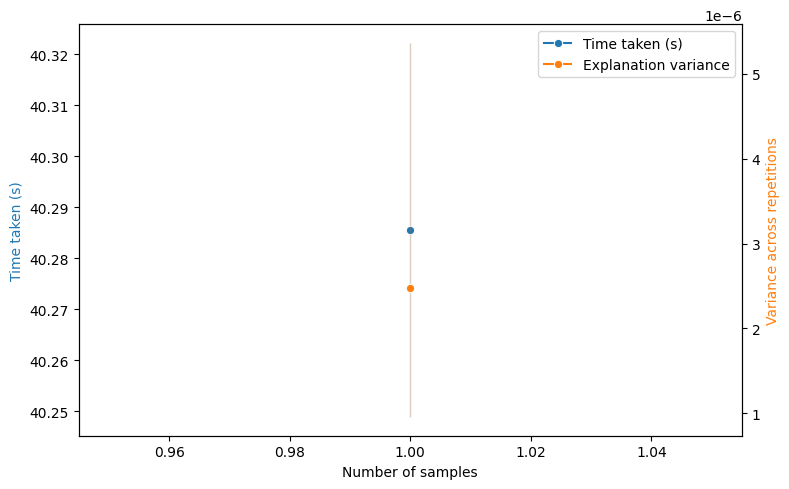

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

df = results_variance_long.copy()

time_color = "tab:blue"
variance_color = "tab:orange"

fig, ax1 = plt.subplots(figsize=(8, 5))

sns.lineplot(
    data=results_long,
    x="num_samples",
    y="time_taken",
    marker="o",
    ax=ax1,
    color=time_color,
    label="Time taken (s)"
)

ax1.set_xlabel("Number of samples")
ax1.set_ylabel("Time taken (s)", color=time_color)
ax1.tick_params(axis="y")

ax2 = ax1.twinx()

sns.lineplot(
    data=df,
    x="num_samples",
    y="explanation_variance",
    marker="o",
    ax=ax2,
    color=variance_color,
    label="Explanation variance"
)

ax2.set_ylabel("Variance across repetitions", color=variance_color)
ax2.tick_params(axis="y")

ax1.get_legend().remove()
ax2.get_legend().remove()

# Combined legend
lines = ax1.get_lines() + ax2.get_lines()
labels = [str(line.get_label()) for line in lines]
ax1.legend(lines, labels, loc="best")

plt.tight_layout()
plt.show()

# TGNN Explainer

In [3]:
from DyGLib.models.modules import MultiHeadAttention
from Explainers.External.tgnnexplainer.Explainer import SubgraphXTExplainer as TGNNExplainer

# Make sure the model is TGAT and set the edge_attention_alter_mode to "add" for all MultiHeadAttention layers
assert isinstance(model.backbone, TGAT), "Model must be an instance of TGAT"
for layer in model.backbone.temporal_conv_layers:
    assert isinstance(layer, MultiHeadAttention), "Layer must be an instance of MultiHeadAttention"
    layer.edge_attention_alter_mode = "add"

exact_explainer = TGNNExplainer(model, full_neighbor_sampler, full_data)
exact_explainer.initialize()

src = 20
dst = 100019
timestamp = 4

explanation = exact_explainer.explain_instance(src, dst, timestamp)

explainer ckpt not found at Data/wikipedia/checkpoints/pg_explainer_tg/tgat_Wikipedia_subgraphx_tg_expl_ckpt.pt
start training...


epoch 0:  91%|█████████ | 912/1000 [07:27<00:43,  2.04it/s]  


KeyboardInterrupt: 

# TempME

In [9]:
from Explainers.External.TempME.Explainer import TempMEExplainer
from Explainers.External.TempME.utils.graph import get_walk_finder
from DyGLib.utils.utils import NegativeEdgeSampler

train_walk_finder = get_walk_finder(train_data)

train_negative_sampler = NegativeEdgeSampler(
    train_data.src_node_ids,
    train_data.dst_node_ids,
    train_data.node_interact_times,
)

full_walk_finder = get_walk_finder(full_data)

full_negative_sampler = NegativeEdgeSampler(
    full_data.src_node_ids,
    full_data.dst_node_ids,
    full_data.node_interact_times,
)

# Training preprocessing
train_explainer = TempMEExplainer(model, train_neighbor_sampler, train_data)
train_explainer.preprocess(train_walk_finder, train_negative_sampler, train=True)
train_explainer.initialize(train=True)

# Evaluation preprocessing
eval_explainer = TempMEExplainer(model, full_neighbor_sampler, full_data)
eval_explainer.preprocess(full_walk_finder, full_negative_sampler, train=False)
eval_explainer.initialize(train=False)

src = 20
dst = 100019
timestamp = 4

explanation = eval_explainer.explain_instance(
    src=src,
    dst=dst,
    timestamp=timestamp,
)
explanation

TempME walks: 100%|██████████| 174/174 [31:25<00:00, 10.84s/it]   


TempME epoch 0: 0.486689
TempME epoch 1: 0.563710
TempME epoch 2: 0.563710
TempME epoch 3: 0.563710
TempME epoch 4: 0.563710
TempME epoch 5: 0.563710
TempME epoch 6: 0.563710
TempME epoch 7: 0.563710


: 

In [7]:
explanation[2].node_attention


[tensor([[1., 1., 1., 1., 1.]]),
 tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
          1., 1., 1., 1., 1., 1., 1.]])]